# Multimodal Song Compatibility (MAEST + Chroma + Tempo)

This notebook computes a next-track compatibility distribution from a seed song using three embeddings:
- MAEST embedding similarity
- Chroma embedding similarity
- Tempo embedding similarity

Seed track in this run: **#10 - Illusion** from `music/aries-mix/aries_mix_tracks.csv`.


In [29]:
from __future__ import annotations

import csv
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "music").exists() and (PROJECT_ROOT.parent / "music").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


def to_project_relpath(path: str | Path) -> str:
    resolved = Path(path).expanduser().resolve()
    try:
        return str(resolved.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(resolved)


from djprojectexploration.multimodal_compatibility import (
    combined_similarity_matrix,
    compatible_song_distribution,
    load_aries_mix_feature_set,
)

print(f"Project root: {PROJECT_ROOT}")



Project root: /Users/josephdaher/Git Repositories/djprojectexploration


In [13]:
features = load_aries_mix_feature_set(
    mix_csv_path=PROJECT_ROOT / "music" / "aries-mix" / "aries_mix_tracks.csv",
    maest_dir=PROJECT_ROOT / "data" / "maest_embeddings",
    chroma_dir=PROJECT_ROOT / "data" / "chroma_embeddings",
    tempo_dir=PROJECT_ROOT / "data" / "tempo_embeddings",
    chroma_use_base_only=True,
)

print(f"Loaded tracks with all three embeddings: {len(features.metadata)}")
print(f"MAEST shape: {features.maest.shape}")
print(f"Chroma shape: {features.chroma.shape}")
print(f"Tempo BPM shape: {features.tempo_bpm.shape}")
print(f"Tempo confidence shape: {features.tempo_confidence.shape}")



Loaded tracks with all three embeddings: 25
MAEST shape: (25, 768)
Chroma shape: (25, 24)
Tempo BPM shape: (25,)
Tempo confidence shape: (25,)


In [31]:
# Editable compatibility parameters (single place to tune behavior)
MAEST_WEIGHT = 0.7
CHROMA_WEIGHT = 0.1
TEMPO_WEIGHT = 0.2

TEMPERATURE = 0.08
CANDIDATE_TOP_K = None
TOP_N = 15
SEED_TRACK_NUMBER = 10

# Tempo similarity parameters
TEMPO_BANDWIDTH = 0.06
TEMPO_DECAY = 0.5
TEMPO_ALLOW_OCTAVE = True
TEMPO_OCTAVE_PENALTY = 0.5
TEMPO_SIMILARITY_SHAPE = 'gaussian'  # one of: gaussian, exp, flat+exp, softflat+exp
TEMPO_SOFTFLAT_SHARPNESS = 8.0
TEMPO_USE_CONFIDENCE = True

# Separate weights for full matrix visualization (if desired)
MATRIX_MAEST_WEIGHT = 0.7
MATRIX_CHROMA_WEIGHT = 0.1
MATRIX_TEMPO_WEIGHT = 0.2


def run_seed_query(
    seed_track_number: int,
    top_n: int = TOP_N,
    maest_weight: float = MAEST_WEIGHT,
    chroma_weight: float = CHROMA_WEIGHT,
    tempo_weight: float = TEMPO_WEIGHT,
    temperature: float = TEMPERATURE,
    candidate_top_k: int | None = CANDIDATE_TOP_K,
    tempo_bandwidth: float = TEMPO_BANDWIDTH,
    tempo_decay: float = TEMPO_DECAY,
    tempo_allow_octave: bool = TEMPO_ALLOW_OCTAVE,
    tempo_octave_penalty: float = TEMPO_OCTAVE_PENALTY,
    tempo_similarity_shape: str = TEMPO_SIMILARITY_SHAPE,
    tempo_softflat_sharpness: float = TEMPO_SOFTFLAT_SHARPNESS,
    tempo_use_confidence: bool = TEMPO_USE_CONFIDENCE,
):
    dist_rows = compatible_song_distribution(
        features=features,
        seed_track_number=int(seed_track_number),
        maest_weight=float(maest_weight),
        chroma_weight=float(chroma_weight),
        tempo_weight=float(tempo_weight),
        temperature=float(temperature),
        candidate_top_k=candidate_top_k,
        tempo_bandwidth=float(tempo_bandwidth),
        tempo_decay=float(tempo_decay),
        tempo_allow_octave=bool(tempo_allow_octave),
        tempo_octave_penalty=float(tempo_octave_penalty),
        tempo_similarity_shape=str(tempo_similarity_shape),
        tempo_softflat_sharpness=float(tempo_softflat_sharpness),
        tempo_use_confidence=bool(tempo_use_confidence),
    )

    seed_meta = None
    for m in features.metadata:
        if m.track_number == int(seed_track_number):
            seed_meta = m
            break
    if seed_meta is None:
        raise ValueError(f"Seed track #{seed_track_number} not found in loaded feature set.")

    print(
        f"Seed/Candidate track: #{seed_meta.track_number} - {seed_meta.title} "
        f"({seed_meta.artist}) [{seed_meta.filename}]"
    )
    print(f"Computed compatibility distribution from seed track #{seed_track_number}.")
    print(f"Candidates in distribution: {len(dist_rows)}")

    try:
        import pandas as pd
        from IPython.display import display

        df_dist = pd.DataFrame(dist_rows)
        display(df_dist.head(int(top_n)))
    except Exception:
        print(f"Top {int(top_n)} candidates:")
        for row in dist_rows[: int(top_n)]:
            print(
                f"#{row['track_number']:02d} {row['title']} | p={row['probability']:.4f} | "
                f"maest={row['maest_similarity']:.3f}, "
                f"chroma={row['chroma_similarity']:.3f}, "
                f"tempo={row['tempo_similarity']:.3f}"
            )

    return seed_meta, dist_rows


# Example run
seed_meta, dist_rows = run_seed_query(
    seed_track_number=SEED_TRACK_NUMBER,
    top_n=TOP_N,
    maest_weight=MAEST_WEIGHT,
    chroma_weight=CHROMA_WEIGHT,
    tempo_weight=TEMPO_WEIGHT,
    temperature=TEMPERATURE,
    candidate_top_k=CANDIDATE_TOP_K,
    tempo_bandwidth=TEMPO_BANDWIDTH,
    tempo_decay=TEMPO_DECAY,
    tempo_allow_octave=TEMPO_ALLOW_OCTAVE,
    tempo_octave_penalty=TEMPO_OCTAVE_PENALTY,
    tempo_similarity_shape=TEMPO_SIMILARITY_SHAPE,
    tempo_softflat_sharpness=TEMPO_SOFTFLAT_SHARPNESS,
    tempo_use_confidence=TEMPO_USE_CONFIDENCE,
)


Seed/Candidate track: #10 - Illusion (Yotto) [illusion.mp3]
Computed compatibility distribution from seed track #10.
Candidates in distribution: 24
Top 15 candidates:
#02 Tears from the Moon (aname Mix) | p=0.0750 | maest=0.962, chroma=0.959, tempo=0.958
#07 Come Alive | p=0.0719 | maest=0.970, chroma=0.817, tempo=0.984
#16 Hold That Sucker Down (HEL:SLOWED Remix) | p=0.0676 | maest=0.960, chroma=0.870, tempo=0.970
#13 Walk the Plank | p=0.0630 | maest=0.962, chroma=0.815, tempo=0.962
#12 Warrior | p=0.0620 | maest=0.971, chroma=0.800, tempo=0.931
#08 Subterranean | p=0.0603 | maest=0.972, chroma=0.738, tempo=0.948
#05 Parasite | p=0.0563 | maest=0.963, chroma=0.685, tempo=0.976
#06 Lately (Adam Ten & Mita Gami Remix) | p=0.0544 | maest=0.973, chroma=0.660, tempo=0.941
#17 Flame | p=0.0541 | maest=0.970, chroma=0.864, tempo=0.847
#14 Power Drive | p=0.0527 | maest=0.965, chroma=0.723, tempo=0.924
#03 Break the Silence | p=0.0521 | maest=0.960, chroma=0.638, tempo=0.981
#04 Love You Got

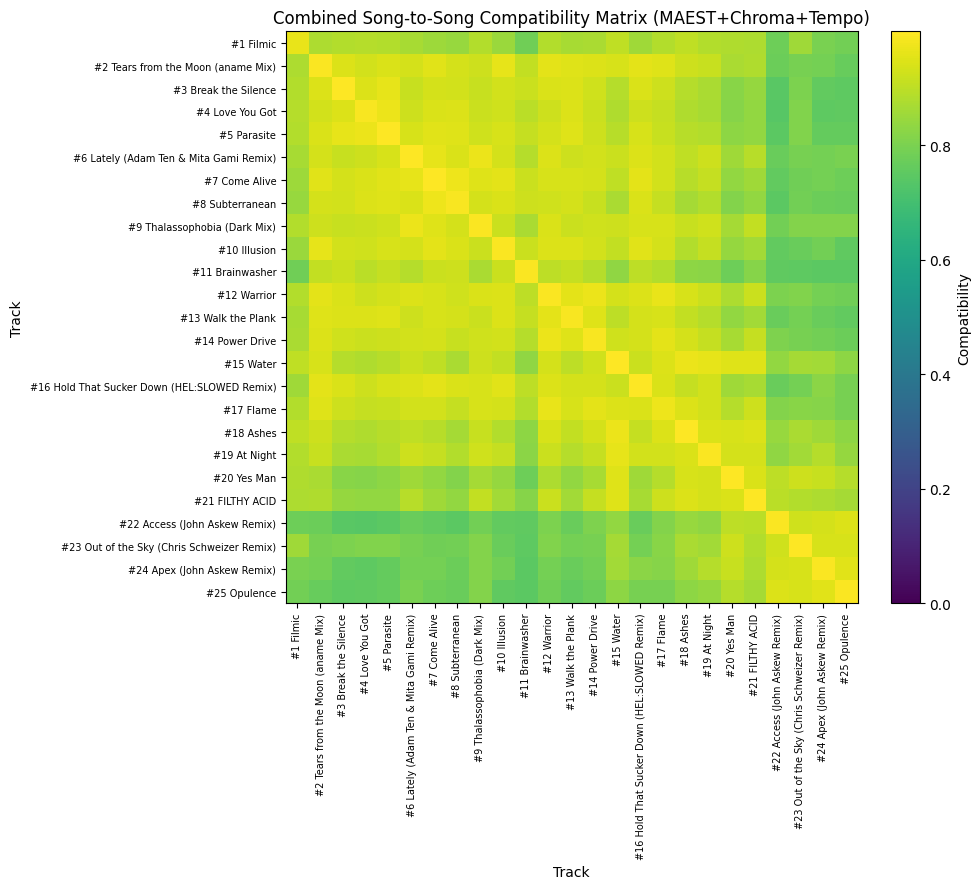

In [32]:
S = combined_similarity_matrix(
    features=features,
    maest_weight=MATRIX_MAEST_WEIGHT,
    chroma_weight=MATRIX_CHROMA_WEIGHT,
    tempo_weight=MATRIX_TEMPO_WEIGHT,
    tempo_bandwidth=TEMPO_BANDWIDTH,
    tempo_decay=TEMPO_DECAY,
    tempo_allow_octave=TEMPO_ALLOW_OCTAVE,
    tempo_octave_penalty=TEMPO_OCTAVE_PENALTY,
    tempo_similarity_shape=TEMPO_SIMILARITY_SHAPE,
    tempo_softflat_sharpness=TEMPO_SOFTFLAT_SHARPNESS,
    tempo_use_confidence=TEMPO_USE_CONFIDENCE,
)

labels = [f"#{m.track_number} {m.title}" for m in features.metadata]

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(S, cmap="viridis", vmin=0.0, vmax=float(np.max(S)))
ax.set_title("Combined Song-to-Song Compatibility Matrix (MAEST+Chroma+Tempo)")
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel("Track")
ax.set_ylabel("Track")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Compatibility")
fig.tight_layout()

# matrix_plot = out_dir / "combined_compatibility_matrix.png"
# matrix_npz = out_dir / "combined_compatibility_matrix.npz"
# fig.savefig(matrix_plot, dpi=220)
plt.show()

# np.savez_compressed(matrix_npz, labels=np.array(labels), compatibility=S)

# print(f"Saved compatibility matrix plot: {to_project_relpath(matrix_plot)}")
# print(f"Saved compatibility matrix data: {to_project_relpath(matrix_npz)}")


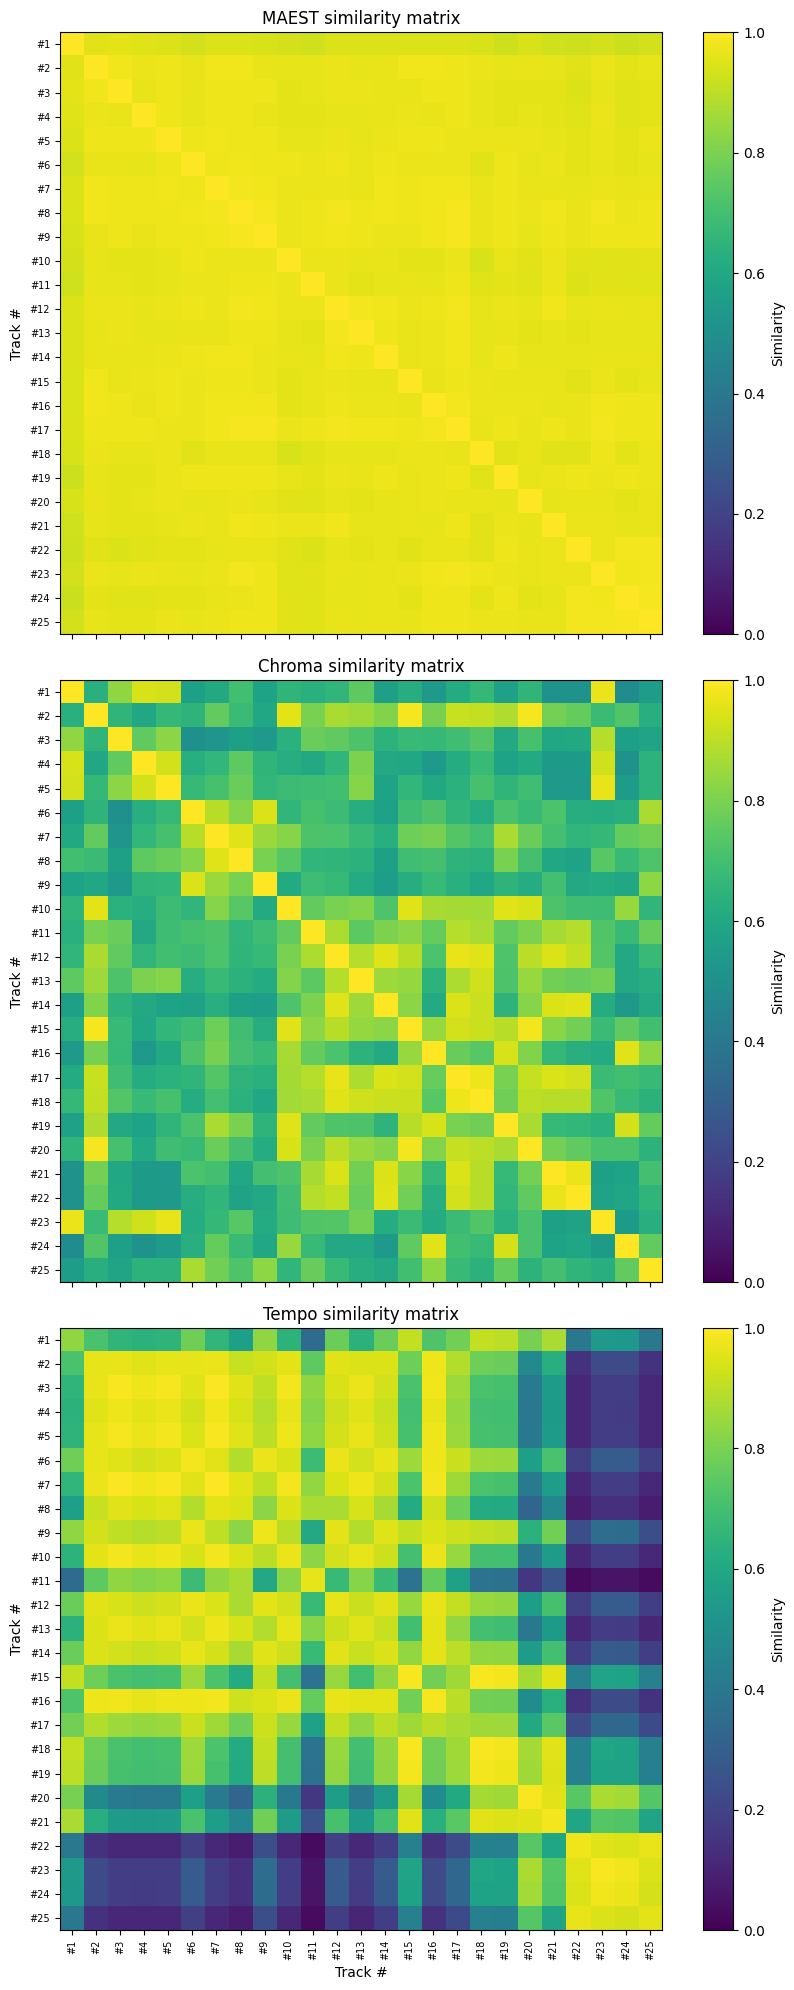

In [ ]:
# Component-only compatibility matrices
labels_num = [f"#{m.track_number}" for m in features.metadata]

component_specs = [
    ("MAEST similarity matrix", 1.0, 0.0, 0.0),
    ("Chroma similarity matrix", 0.0, 1.0, 0.0),
    ("Tempo similarity matrix", 0.0, 0.0, 1.0),
]

fig, axes = plt.subplots(3, 1, figsize=(11, 20), sharex=True, sharey=True)

for i, (ax, (title, w_maest, w_chroma, w_tempo)) in enumerate(zip(axes, component_specs)):
    M = combined_similarity_matrix(
        features=features,
        maest_weight=w_maest,
        chroma_weight=w_chroma,
        tempo_weight=w_tempo,
        tempo_bandwidth=TEMPO_BANDWIDTH,
        tempo_decay=TEMPO_DECAY,
        tempo_allow_octave=TEMPO_ALLOW_OCTAVE,
        tempo_octave_penalty=TEMPO_OCTAVE_PENALTY,
        tempo_similarity_shape=TEMPO_SIMILARITY_SHAPE,
        tempo_softflat_sharpness=TEMPO_SOFTFLAT_SHARPNESS,
        tempo_use_confidence=TEMPO_USE_CONFIDENCE,
    )
    im = ax.imshow(M, cmap="viridis", vmin=0.0, vmax=1.0)
    ax.set_title(title)
    ax.set_ylabel("Track #")
    ax.set_xticks(np.arange(len(labels_num)))
    ax.set_yticks(np.arange(len(labels_num)))
    ax.set_xticklabels(labels_num, rotation=90, fontsize=7)
    ax.set_yticklabels(labels_num, fontsize=7)
    if i < 2:
        ax.tick_params(axis="x", labelbottom=False)
    else:
        ax.set_xlabel("Track #")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Similarity")

fig.tight_layout()
plt.show()
